# Experiment 4: Backbone Comparison for Jaguar Re-Identification

**Research Question:** Which backbone feature extractor when frozen and used with an identical ArcFace projection head and training protocol yields the highest identity-balanced mAP for jaguar re-identification?

## Overview

1. **Data Loading**: Stratified train/validation split ensuring all identities appear in both sets
2. **Backbone Comparison**: Extract embeddings from 4 frozen backbones under identical conditions
3. **ArcFace Training**: Same projection head, loss, optimizer, and schedule for all backbones
4. **Evaluation**: Identity-balanced mAP on validation set for each backbone
5. **Submission**: Generate submission using the best-performing backbone

## Backbones Compared 

| Backbone | Type | Pretrained On | Embed Dim |
|----------|------|---------------|-----------|
| **MegaDescriptor-L-384** | ViT-L (Swin) | Wildlife Re-ID datasets | 1536 |
| **DINOv2-ViT-L/14** | ViT-L | LVD-142M (self-supervised) | 1024 |
| **EfficientNet-B4** | CNN | ImageNet | 1792 |
| **ConvNeXt-V2-Base** | CNN-Transformer | ImageNet-22K | 1024 |
| **ResNet-50** | CNN | ImageNet | 2048 |

## Controlled Variables (Same Across ALL Backbones)
- All backbones: **frozen** (no gradient updates to backbone weights)
- Projection head: Linear(backbone_dim → 512 → 256), BatchNorm, ReLU, Dropout(0.3)
- Loss: **ArcFace** (margin=0.5, scale=64) — same as Experiment 1 baseline
- Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)
- Epochs: 50, Batch size: 32, Seed: 42
- Embedding dim: 256 (output of projection head — same for all)
- Augmentations: RandomHorizontalFlip, ColorJitter, RandomRotation
- Evaluation: Identity-balanced mAP on fixed val split (val_split=0.2)

## 1. Setup and Configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import wandb
from dotenv import load_dotenv

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]= user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

#Load environment variables from .env file
#The .env file should contain: WANDB_API_KEY, WANDB_PROJECT, HF_TOKEN
env_path = Path("../../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

PyTorch version: 2.8.0+cu126
timm version: 1.0.20


In [2]:
secret_value_1 = user_secrets.get_secret("wandb_api")
print(len(secret_value_1))

86


In [3]:
# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

Using CUDA GPU
Device: cuda


In [4]:
# Controlled variables: SAME for all backbones
RANDOM_SEED = 42

BACKBONE_CONFIGS = [
    {
        "name": "MegaDescriptor-L-384",
        "model_id": "hf-hub:BVRA/MegaDescriptor-L-384",
        "input_size": 384,
        "embed_dim": 1536,
        "type": "timm",
    },
    {
        "name": "DINOv2-ViT-L-14",
        "model_id": "vit_large_patch14_dinov2.lvd142m",
        "input_size": 518,
        "embed_dim": 1024,
        "type": "timm",
    },
    {
        "name": "EfficientNet-B4",
        "model_id": "efficientnet_b4",
        "input_size": 380,
        "embed_dim": 1792,
        "type": "timm",
    },
    {
        "name": "ConvNeXt-V2-Base",
        "model_id": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "input_size": 384,
        "embed_dim": 1024,
        "type": "timm",
    },
        {
            "name": "ResNet-50",
            "model_id": "resnet50",
            "input_size": 224,
            "embed_dim": 2048,
            "type": "timm",
        },
]

config = {
    # Paths
    "data_dir": Path("/kaggle/input/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints"),

    # Shared model settings
    "embedding_dim": 256,   # output of projection head (same for all backbones)
    "hidden_dim": 512,

    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,

    # Training (same for all backbones)
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,

    # Reproducibility
    "seed": RANDOM_SEED,
}

# Create checkpoint directory
config["checkpoint_dir"].mkdir(exist_ok=True)

print("Backbone Comparison Configuration:")
print(f"  Embedding dim (all backbones): {config['embedding_dim']}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")
print(f"  Learning rate: {config['learning_rate']}")
print(f"  Epochs per backbone: {config['num_epochs']}")
print(f"\nBackbones to compare:")
for b in BACKBONE_CONFIGS:
    print(f"  - {b['name']} (input: {b['input_size']}px, dim: {b['embed_dim']})")

Backbone Comparison Configuration:
  Embedding dim (all backbones): 256
  ArcFace margin: 0.5
  ArcFace scale: 64.0
  Learning rate: 0.0001
  Epochs per backbone: 50

Backbones to compare:
  - MegaDescriptor-L-384 (input: 384px, dim: 1536)
  - DINOv2-ViT-L-14 (input: 518px, dim: 1024)
  - EfficientNet-B4 (input: 380px, dim: 1792)
  - ConvNeXt-V2-Base (input: 384px, dim: 1024)
  - ResNet-50 (input: 224px, dim: 2048)


In [5]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# Initialize Weights and Biases for experiment tracking
# Backbone Comparison - run name updated to reflect experiment
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        # Experiment info
        "experiment": "backbone-comparison",
        "backbones_compared": ["MegaDescriptor-L-384", "DINOv2-ViT-L/14", "EfficientNet-B4", "ConvNeXt-V2-Base"],
        "num_backbones": 4,
        # Model architecture (same for all backbones)
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "dropout": config["dropout"],
        # ArcFace hyperparameters (same for all backbones)
        "arcface_margin": config["arcface_margin"],
        "arcface_scale": config["arcface_scale"],
        # Training hyperparameters (same for all backbones)
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "num_epochs": config["num_epochs"],
        "patience": config["patience"],
        "val_split": config["val_split"],
        "seed": config["seed"],
    },
    name="backbone-comparison",
)
print("W&B initialized for Backbone Comparison experiment")
print(f"  Project: {os.getenv('WANDB_PROJECT', 'jaguar-reid-iota')}")
print(f"  Run name: backbone-comparison")
print(f"  Backbones: MegaDescriptor-L-384, DINOv2-ViT-L/14, EfficientNet-B4, ConvNeXt-V2-Base")
print(f"  ArcFace margin: {config['arcface_margin']} ({config['arcface_margin'] * 180 / 3.14159:.1f}°)")
print(f"  ArcFace scale: {config['arcface_scale']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")

W&B initialized for Backbone Comparison experiment
  Project: jaguar-reid-iota
  Run name: backbone-comparison
  Backbones: MegaDescriptor-L-384, DINOv2-ViT-L/14, EfficientNet-B4, ConvNeXt-V2-Base
  ArcFace margin: 0.5 (28.6°)
  ArcFace scale: 64.0
  Embedding dim: 256
  Dropout: 0.3


## 2. Load and Prepare Data

We load the training data from `train.csv` which contains image filenames and their corresponding jaguar identity labels. The key challenge is creating a proper train/validation split:

**Stratified Split**: We ensure every jaguar identity appears in both the training and validation sets. This is critical because:
1. The model must learn to recognize all individuals during training
2. Validation mAP should reflect performance across all identities
3. Identities with few images still need representation in both sets

In [7]:
# Load training data
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1


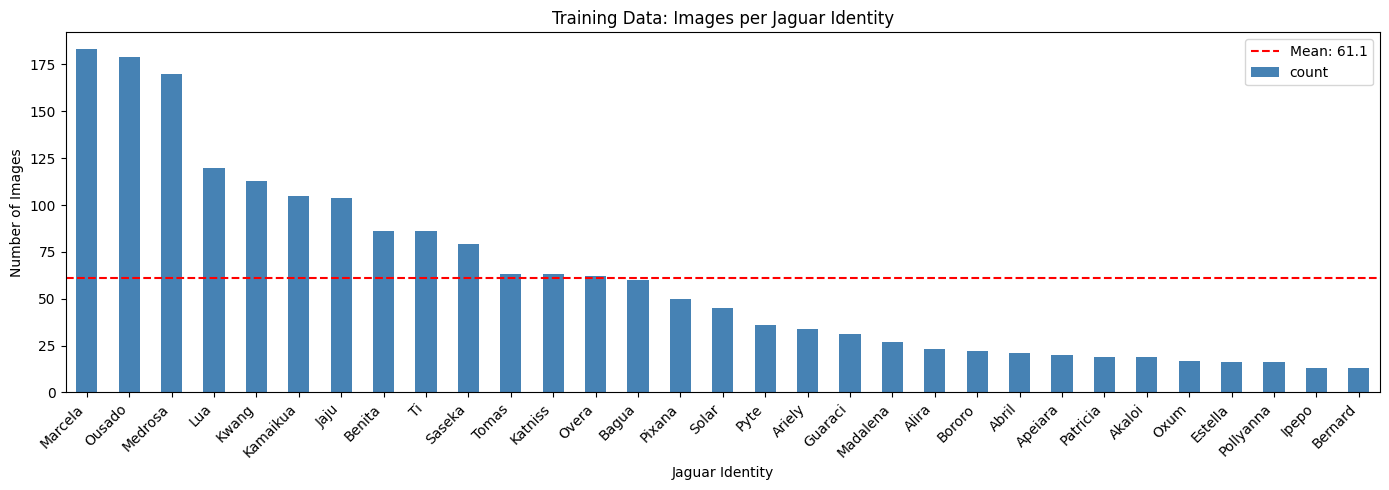

In [8]:
# Visualize identity distribution and log to W&B
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--', label=f'Mean: {identity_counts.mean():.1f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Log to W&B
wandb.log({"identity_distribution_full": wandb.Image(fig)})
plt.show()

# Identify identities that may need careful handling (few samples)
min_samples_for_split = 2  # Need at least 2 to split
low_sample_identities = identity_counts[identity_counts < min_samples_for_split]

if len(low_sample_identities) > 0:   
    print(f"\nWarning: {len(low_sample_identities)} identities have fewer than {min_samples_for_split} images")

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


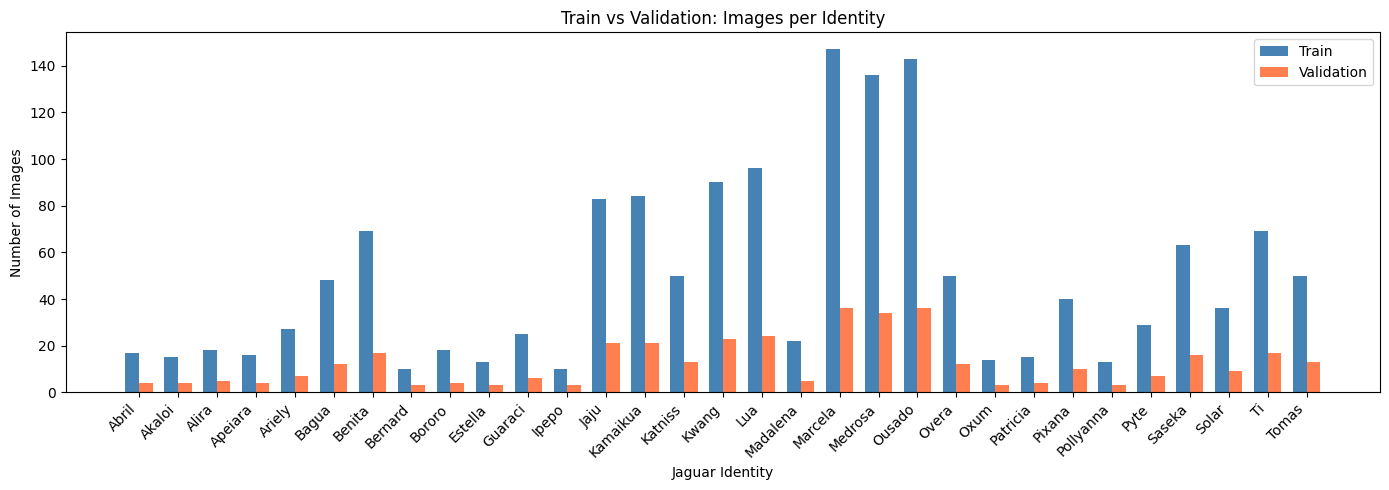


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [9]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## 3. Load MegaDescriptor Model

MegaDescriptor is a Vision Transformer (ViT-L/14) trained specifically for wildlife re-identification. It was trained on multiple species datasets and produces 1536-dimensional embeddings.

We use the `timm` library to load the pre-trained model from Hugging Face Hub.

In [10]:
# Load all 4 backbones using timm - all frozen (no gradient updates)

def load_backbone(backbone_cfg, device):
    """Load a timm backbone and return model + embedding dim."""
    print(f"Loading {backbone_cfg['name']}...")
    # CNN-based models (EfficientNet, ConvNeXt, ResNet) don't accept img_size kwarg
    cnn_types = ['efficientnet', 'convnext', 'resnet']
    model_id_lower = backbone_cfg['model_id'].lower()
    is_cnn = any(cnn in model_id_lower for cnn in cnn_types)
    if is_cnn:
        model = timm.create_model(
            backbone_cfg["model_id"],
            pretrained=True,
            num_classes=0,  # Remove classifier head -> returns embeddings
        )
    else:
        model = timm.create_model(
            backbone_cfg["model_id"],
            pretrained=True,
            num_classes=0,  # Remove classifier head -> returns embeddings
            img_size=backbone_cfg["input_size"],
        )
    model.eval()
    # Freeze ALL backbone weights (controlled variable)
    for param in model.parameters():
        param.requires_grad = False
    model.to(device)
    # Auto-detect embedding dimension
    input_size = backbone_cfg["input_size"]
    with torch.no_grad():
        dummy = torch.randn(1, 3, input_size, input_size).to(device)
        out = model(dummy)
        embed_dim = out.shape[1]
    print(f"  Embedding dim: {embed_dim}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Frozen: True (no gradient updates)")
    return model, embed_dim

def get_transforms(input_size, augment=False):
    """Get image transforms for a given input size."""
    if augment:
        return transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
print("Backbone loading function defined.")
print("Will load all 4 backbones sequentially during training loop.")

Backbone loading function defined.
Will load all 4 backbones sequentially during training loop.


In [11]:
# This legacy cell just prints a note about backbone-specific transforms
print("Each backbone uses get_transforms(input_size) with its own input_size.")
print("Backbone input sizes:")
for bb in BACKBONE_CONFIGS:
    print(f"  - {bb['name']}: {bb['input_size']}x{bb['input_size']}")

Each backbone uses get_transforms(input_size) with its own input_size.
Backbone input sizes:
  - MegaDescriptor-L-384: 384x384
  - DINOv2-ViT-L-14: 518x518
  - EfficientNet-B4: 380x380
  - ConvNeXt-V2-Base: 384x384
  - ResNet-50: 224x224


In [12]:
@torch.no_grad()
def extract_embeddings(model, image_paths, transform, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using any backbone model."""
    model.eval()
    embeddings = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]

        # Load and preprocess batch
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = transform(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                # Use zero tensor as fallback
                batch_tensors.append(torch.zeros(3, 224, 224))

        # Stack and move to device
        batch_tensor = torch.stack(batch_tensors).to(device)

        # Get embeddings
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)

    return np.vstack(embeddings)

print("extract_embeddings function updated to accept transform parameter")

extract_embeddings function updated to accept transform parameter


In [13]:
# Prepare image paths for train and val sets
# Embeddings will be extracted PER BACKBONE inside the training loop
train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [config["data_dir"] / "train/train" / fn for fn in train_filenames]

val_filenames = val_data["filename"].astype(str).tolist()
val_image_paths = [config["data_dir"] / "train/train" / fn for fn in val_filenames]

print(f"Train image paths: {len(train_image_paths)}")
print(f"Val image paths: {len(val_image_paths)}")
print("Each backbone uses its own input size and produces different embedding dimensions.")

Train image paths: 1516
Val image paths: 379
Each backbone uses its own input size and produces different embedding dimensions.


## 4. Visualize Baseline Embeddings with MDS

Multidimensional Scaling (MDS) projects high-dimensional embeddings to 2D while preserving pairwise distances. For embeddings on a hypersphere (L2-normalized), we use geodesic distances (arc length) rather than Euclidean distances.

This visualization shows how well MegaDescriptor separates different jaguars before any fine-tuning.

In [14]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    # Normalize embeddings to unit sphere
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    
    # Compute cosine similarity
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    
    # Convert to geodesic distance (arc length)
    geodesic_dist = np.arccos(cos_sim)
    
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    # Subsample if too many points (MDS is O(n^3))
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]
    
    # Compute geodesic distance matrix
    dist_matrix = compute_geodesic_distances(embeddings)
    
    # Apply MDS
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)
    
    # Create color mapping for identities
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    for label in unique_labels:
        mask = labels == label
        ax.scatter(
            coords_2d[mask, 0], 
            coords_2d[mask, 1],
            c=[label_to_color[label]],
            label=label,
            alpha=0.7,
            s=30
        )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    
    # Legend outside plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    
    return fig

print("MDS visualization functions defined")

MDS visualization functions defined


In [15]:
train_labels = train_data['ground_truth'].values
print("Baseline MDS visualization skipped (will be done for best backbone after training)")
print(f"Train labels: {len(train_labels)} images, {len(set(train_labels))} identities")

Baseline MDS visualization skipped (will be done for best backbone after training)
Train labels: 1516 images, 31 identities


## 5. Define Model Architecture

We define two components:

1. **EmbeddingProjection**: Projects 1536-dim MegaDescriptor embeddings to 256-dim. This learned projection optimizes the embedding space for our specific jaguar dataset.

2. **ArcFaceLayer**: Implements Additive Angular Margin Loss. It:
   - Normalizes embeddings to unit length (projects to hypersphere)
   - Computes cosine similarity to class weight vectors
   - Adds angular margin to the ground truth class before softmax
   - Scales logits to sharpen the distribution

In [16]:
class EmbeddingProjection(nn.Module):
    """
    Projects MegaDescriptor embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        output = output * self.scale
        
        return output


print("EmbeddingProjection and ArcFaceLayer defined")

EmbeddingProjection and ArcFaceLayer defined


In [17]:
class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""
    
    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim, 
            hidden_dim=hidden_dim, output_dim=embedding_dim, dropout=dropout
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim, 
            num_classes=num_classes, margin=margin, 
            scale=scale
        )
        
    def forward(self, x, labels):
        """Forward pass for training (requires labels for ArcFace)."""
        embeddings = self.embedding_net(x)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings
        
    def get_embeddings(self, x):
        """Get normalized embeddings for inference."""
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)

# Model creation happens inside training loop (Section 8) per backbone
# Each backbone gets its own ArcFaceModel with backbone-specific input_dim
print("ArcFaceModel class defined.")
print("Model will be created per backbone in Section 8 training loop.")
print(f"Output embedding dim: {config['embedding_dim']} (same for ALL backbones)")

ArcFaceModel class defined.
Model will be created per backbone in Section 8 training loop.
Output embedding dim: 256 (same for ALL backbones)


## 6. Prepare DataLoaders

We create PyTorch datasets from the pre-computed MegaDescriptor embeddings. This is more efficient than loading images during training since embedding extraction is the bottleneck.

In [18]:
# This cell just defines the EmbeddingDataset class used in the training loop
class EmbeddingDataset(Dataset):
    """Dataset wrapping pre-extracted embeddings and labels."""
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

print("EmbeddingDataset class defined.")

EmbeddingDataset class defined.


In [19]:
# Each backbone gets its own DataLoader with backbone-specific embeddings
print("EmbeddingDataset and DataLoader creation handled per-backbone")
print(f"Batch size: {config['batch_size']}")
print(f"Number of backbones to train: {len(BACKBONE_CONFIGS)}")

EmbeddingDataset and DataLoader creation handled per-backbone
Batch size: 32
Number of backbones to train: 5


## 7. Training Setup

We set up:
- **CrossEntropyLoss**: Standard classification loss (ArcFace returns logits)
- **AdamW optimizer**: Adam with decoupled weight decay
- **ReduceLROnPlateau scheduler**: Reduces learning rate when validation loss plateaus
- **Early stopping**: Stops training when no improvement for `patience` epochs

We also define a function to compute validation mAP, which simulates the competition metric on the validation set.

In [20]:
def compute_validation_map(model, val_embeddings, val_labels, label_encoder):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    with torch.no_grad():
        # Get fine-tuned embeddings
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()
    
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity
    
    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [21]:
# Each backbone gets its own fresh model, optimizer, and scheduler
# Controlled variables (same for all):
print("Training Setup (controlled variables, same for ALL backbones):")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Epochs: {config['num_epochs']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Embedding dim (output): {config['embedding_dim']}")
print(f"  Projection head: Linear(backbone_dim -> 512 -> 256), BN, ReLU, Dropout({config['dropout']})")
print(f"  ArcFace margin: {config['arcface_margin']}, scale: {config['arcface_scale']}")

Training Setup (controlled variables, same for ALL backbones):
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
  Epochs: 50
  Batch size: 32
  Embedding dim (output): 256
  Projection head: Linear(backbone_dim -> 512 -> 256), BN, ReLU, Dropout(0.3)
  ArcFace margin: 0.5, scale: 64.0


In [22]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)
            
            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training and validation functions defined")

Training and validation functions defined


## 8. Training Loop

We train the model with:
- Validation loss and mAP computed each epoch
- Best model checkpointed based on lowest validation loss
- Early stopping if no improvement for `patience` epochs
- All metrics logged to Weights and Biases

In [23]:
# Trains the same ArcFace projection head for each backbone under IDENTICAL conditions
# Results are stored in backbone_results for comparison

backbone_results = {}  # Will store results for each backbone
best_overall_backbone = None
best_overall_map = 0.0

for bb_cfg in BACKBONE_CONFIGS:
    bb_name = bb_cfg["name"]
    print(f"\n" + "="*70)
    print(f"TRAINING BACKBONE: {bb_name}")
    print("="*70)

    # 1. Load backbone (frozen)
    backbone, backbone_dim = load_backbone(bb_cfg, device)
    transform = get_transforms(bb_cfg["input_size"], augment=False)

    # 2. Extract embeddings for train and val
    print(f"\nExtracting embeddings for {bb_name}...")
    bb_train_embeddings = extract_embeddings(
        backbone, train_image_paths, transform,
        batch_size=config["batch_size"],
        desc=f"{bb_name} train"
    )
    bb_val_embeddings = extract_embeddings(
        backbone, val_image_paths, transform,
        batch_size=config["batch_size"],
        desc=f"{bb_name} val"
    )
    print(f"  Train embeddings: {bb_train_embeddings.shape}")
    print(f"  Val embeddings: {bb_val_embeddings.shape}")

    # 3. Build ArcFace model with this backbone's embedding dim
    model = ArcFaceModel(
        input_dim=backbone_dim,
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        margin=config["arcface_margin"],
        scale=config["arcface_scale"],
        dropout=config["dropout"]
    ).to(device)

    # 4. Create dataloaders
    train_dataset_bb = EmbeddingDataset(bb_train_embeddings, train_data['label_encoded'].values)
    val_dataset_bb = EmbeddingDataset(bb_val_embeddings, val_data['label_encoded'].values)
    train_loader_bb = DataLoader(train_dataset_bb, batch_size=config["batch_size"], shuffle=True, num_workers=0)
    val_loader_bb = DataLoader(val_dataset_bb, batch_size=config["batch_size"], shuffle=False, num_workers=0)

    # 5. Optimizer and scheduler (same for all backbones)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # 6. Training loop (15 epochs per backbone)
    history = {'train_loss': [], 'val_loss': [], 'val_map': [], 'lr': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_map = 0.0
    patience_counter = 0
    best_epoch = 0
    checkpoint_path = config["checkpoint_dir"] / f"{bb_name.replace('/', '-')}_best.pth"

    for epoch in range(config['num_epochs']):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader_bb, criterion, optimizer, device)
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader_bb, criterion, device)
        # Compute mAP
        val_map = compute_validation_map(
            model, bb_val_embeddings, val_data['ground_truth'].values, label_encoder
        )
        # Scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        # Log to W&B with backbone prefix
        wandb.log({
            f"{bb_name}/epoch": epoch + 1,
            f"{bb_name}/train_loss": train_loss,
            f"{bb_name}/train_acc": train_acc,
            f"{bb_name}/val_loss": val_loss,
            f"{bb_name}/val_acc": val_acc,
            f"{bb_name}/val_map": val_map,
            f"{bb_name}/lr": current_lr,
        })
        print(f"  Epoch {epoch+1:2d}/{config['num_epochs']} | Loss: {train_loss:.4f} | Val mAP: {val_map:.4f} | LR: {current_lr:.6f}")
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                        'val_loss': val_loss, 'val_map': val_map, 'backbone': bb_name}, str(checkpoint_path))
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # 7. Log backbone summary to W&B
    wandb.log({
        f"{bb_name}/best_val_map": best_map,
        f"{bb_name}/best_epoch": best_epoch,
        f"{bb_name}/backbone_dim": backbone_dim,
    })
    backbone_results[bb_name] = {
        'best_map': best_map, 'best_epoch': best_epoch,
        'history': history, 'checkpoint': str(checkpoint_path),
        'backbone_dim': backbone_dim
    }
    print(f"\n  {bb_name} DONE: Best mAP = {best_map:.4f} at epoch {best_epoch}")
    # Track overall best
    if best_map > best_overall_map:
        best_overall_map = best_map
        best_overall_backbone = bb_name
    # Free memory before next backbone
    del backbone, model, train_dataset_bb, val_dataset_bb
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n" + "="*70)
print("BACKBONE COMPARISON RESULTS")
print("="*70)
for name, res in backbone_results.items():
    print(f"  {name:30s} | mAP: {res['best_map']:.4f} | Best Epoch: {res['best_epoch']}")
print(f"\nBEST BACKBONE: {best_overall_backbone} (mAP = {best_overall_map:.4f})")
wandb.log({"best_backbone": best_overall_backbone, "best_backbone_map": best_overall_map})


TRAINING BACKBONE: MegaDescriptor-L-384
Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  Embedding dim: 1536
  Parameters: 195,198,516
  Frozen: True (no gradient updates)

Extracting embeddings for MegaDescriptor-L-384...


MegaDescriptor-L-384 train:   0%|          | 0/48 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch 49/50 | Loss: 1.6945 | Val mAP: 0.7638 | LR: 0.000100


Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch 50/50 | Loss: 1.5542 | Val mAP: 0.7671 | LR: 0.000100

  ResNet-50 DONE: Best mAP = 0.7671 at epoch 50

BACKBONE COMPARISON RESULTS
  MegaDescriptor-L-384           | mAP: 0.7720 | Best Epoch: 49
  DINOv2-ViT-L-14                | mAP: 0.8447 | Best Epoch: 50
  EfficientNet-B4                | mAP: 0.8266 | Best Epoch: 50
  ConvNeXt-V2-Base               | mAP: 0.8273 | Best Epoch: 49
  ResNet-50                      | mAP: 0.7671 | Best Epoch: 50

BEST BACKBONE: DINOv2-ViT-L-14 (mAP = 0.8447)


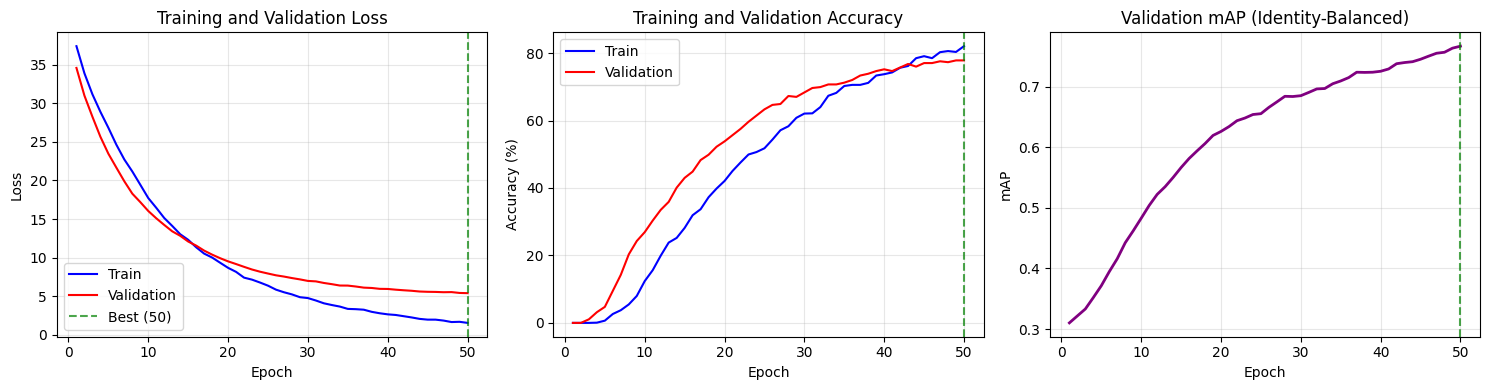

In [24]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# mAP
axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAP')
axes[2].set_title('Validation mAP (Identity-Balanced)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config["checkpoint_dir"] / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves": wandb.Image(fig)})

## 9. Visualize Fine-tuned Embeddings

After training, we visualize the fine-tuned embeddings using MDS and compare them to the baseline. We expect to see tighter clusters for each identity after ArcFace training.

Backbone Comparison - Final Results:
  MegaDescriptor-L-384           | mAP: 0.7720 | Epoch: 49
  DINOv2-ViT-L-14                | mAP: 0.8447 | Epoch: 50 << BEST
  EfficientNet-B4                | mAP: 0.8266 | Epoch: 50
  ConvNeXt-V2-Base               | mAP: 0.8273 | Epoch: 49
  ResNet-50                      | mAP: 0.7671 | Epoch: 50

Best backbone: DINOv2-ViT-L-14 (mAP = 0.8447)


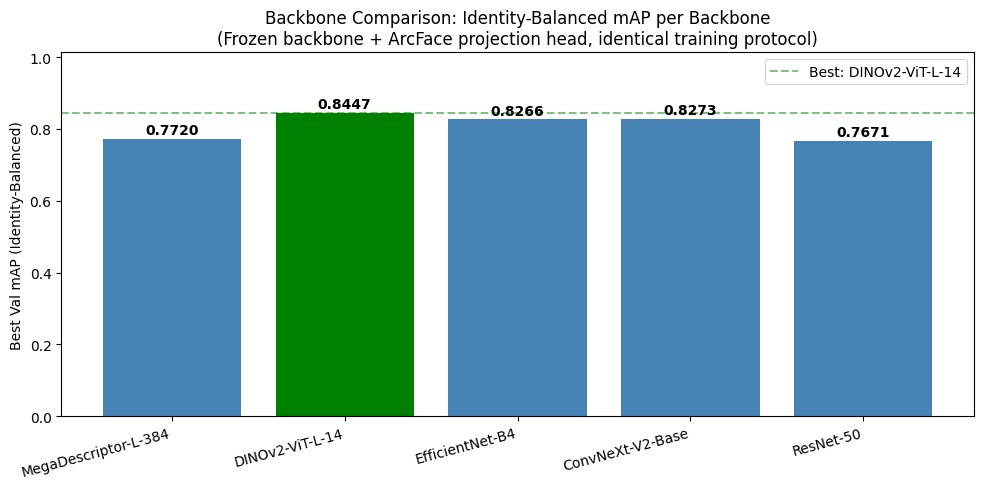

Backbone comparison chart saved and logged to W&B


In [25]:
# Backbone Comparison Bar Chart Visualization
# Compare best mAP of all 4 backbones in a bar chart
print("Backbone Comparison - Final Results:")
print("=" * 60)

backbone_names = list(backbone_results.keys())
maps = [backbone_results[bb]['best_map'] for bb in backbone_names]
best_epochs = [backbone_results[bb]['best_epoch'] for bb in backbone_names]

for name, m, ep in zip(backbone_names, maps, best_epochs):
    marker = " << BEST" if name == best_overall_backbone else ""
    print(f"  {name:30s} | mAP: {m:.4f} | Epoch: {ep}{marker}")

print(f"\nBest backbone: {best_overall_backbone} (mAP = {best_overall_map:.4f})")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if name == best_overall_backbone else 'steelblue' for name in backbone_names]
bars = ax.bar(backbone_names, maps, color=colors)
for bar, val in zip(bars, maps):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Best Val mAP (Identity-Balanced)')
ax.set_title('Backbone Comparison: Identity-Balanced mAP per Backbone\n(Frozen backbone + ArcFace projection head, identical training protocol)')
ax.set_ylim(0, max(maps) * 1.2)
ax.axhline(y=max(maps), color='green', linestyle='--', alpha=0.5, label=f'Best: {best_overall_backbone}')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
# Log to W&B
wandb.log({"backbone_comparison_bar_chart": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'backbone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Backbone comparison chart saved and logged to W&B")

In [27]:
#Load best backbone and re-extract embeddings for visualization
# We reload the best backbone to visualize its fine-tuned embedding space
best_bb_cfg = next(b for b in BACKBONE_CONFIGS if b['name'] == best_overall_backbone)
best_checkpoint_path = backbone_results[best_overall_backbone]['checkpoint']

# Reload best backbone
best_backbone_model, best_backbone_dim = load_backbone(best_bb_cfg, device)
best_transform = get_transforms(best_bb_cfg['input_size'], augment=False)

# Re-extract embeddings with best backbone
print(f"\nRe-extracting embeddings with best backbone: {best_overall_backbone}")
best_bb_train_embeddings = extract_embeddings(
    best_backbone_model, train_image_paths, best_transform,
    batch_size=config['batch_size'], desc="Best backbone train"
)
best_bb_val_embeddings = extract_embeddings(
    best_backbone_model, val_image_paths, best_transform,
    batch_size=config['batch_size'], desc="Best backbone val"
)

# Rebuild model for best backbone and load checkpoint
best_model = ArcFaceModel(
    input_dim=best_backbone_dim, num_classes=num_classes,
    embedding_dim=config['embedding_dim'], hidden_dim=config['hidden_dim'],
    margin=config['arcface_margin'], scale=config['arcface_scale'], dropout=config['dropout']
).to(device)
checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

# Extract fine-tuned embeddings
with torch.no_grad():
    train_tensor = torch.FloatTensor(best_bb_train_embeddings).to(device)
    finetuned_train_embeddings = best_model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Best model loaded from epoch {checkpoint['epoch']}")
print(f"Best val mAP: {checkpoint['val_map']:.4f}")

Loading DINOv2-ViT-L-14...
  Embedding dim: 1024
  Parameters: 304,367,616
  Frozen: True (no gradient updates)

Re-extracting embeddings with best backbone: DINOv2-ViT-L-14


Best backbone train:   0%|          | 0/48 [00:00<?, ?it/s]

Best backbone val:   0%|          | 0/12 [00:00<?, ?it/s]

Fine-tuned embeddings shape: (1516, 256)
Best model loaded from epoch 50
Best val mAP: 0.8447


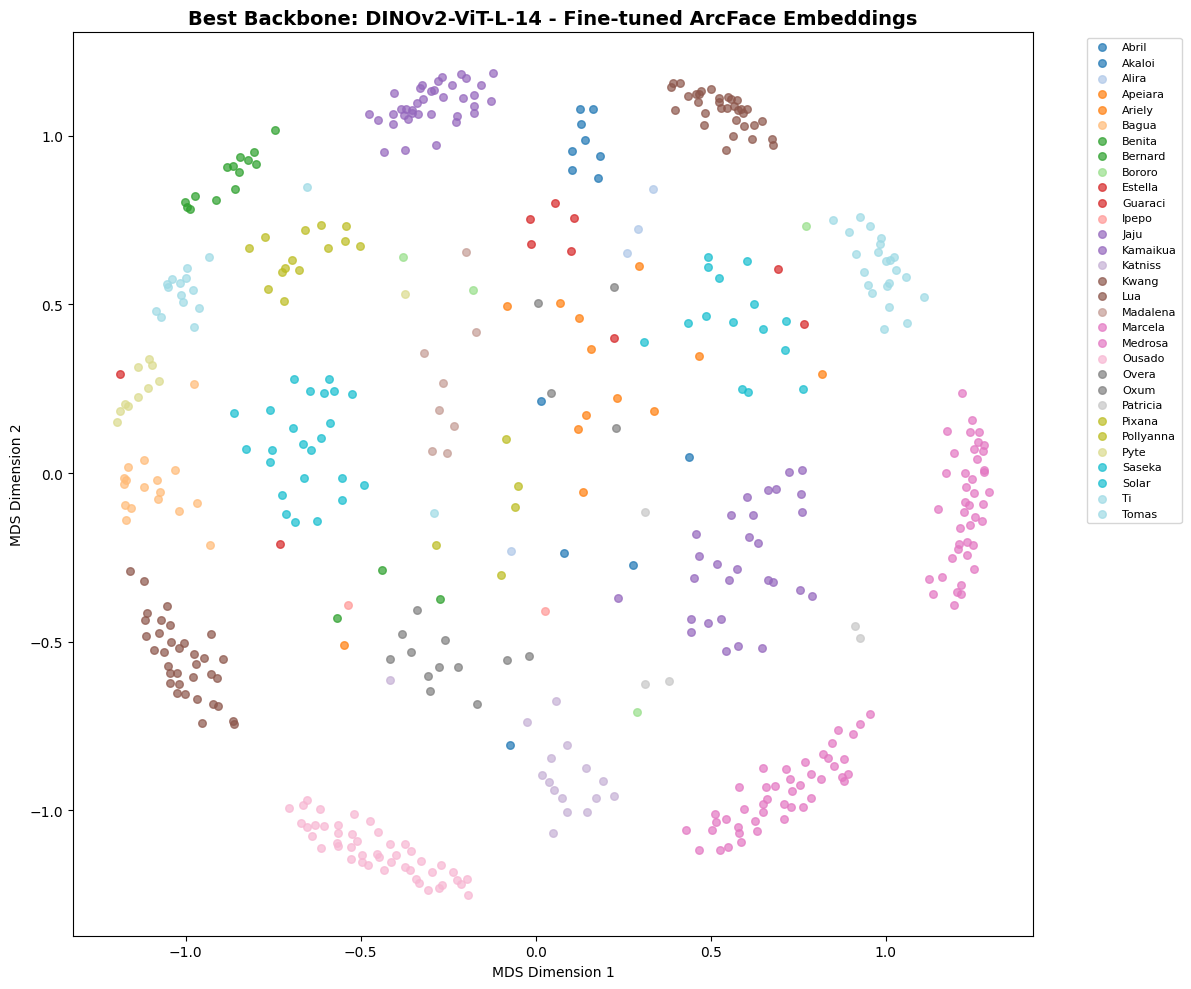

In [28]:
# Visualize fine-tuned embeddings for best backbone using MDS
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings,
    train_labels,
    f"Best Backbone: {best_overall_backbone} - Fine-tuned ArcFace Embeddings"
)
plt.show()
# Log to W&B
wandb.log({"finetuned_embeddings_mds_best_backbone": wandb.Image(fig_finetuned)})

In [29]:
def visualize_nearest_neighbors(
    query_idx,
    original_embeddings,
    finetuned_embeddings,
    image_paths,
    labels,
    k=5,
    title_prefix="Validation"
):
    """
    Visualize the k nearest neighbors of a query image before and after fine-tuning.
    
    Args:
        query_idx: Index of query image in the validation set
        original_embeddings: Original MegaDescriptor embeddings (N, D1)
        finetuned_embeddings: Fine-tuned embeddings (N, D2)
        image_paths: List of image file paths
        labels: Array of identity labels
        k: Number of nearest neighbors to show (default: 5)
        title_prefix: Prefix for the plot title
    
    Returns:
        fig: Matplotlib figure
        stats: Dictionary with comparison statistics
    """
    # Get query info
    query_label = labels[query_idx]
    query_path = image_paths[query_idx]
    
    # Normalize embeddings
    orig_norm = original_embeddings / np.linalg.norm(original_embeddings, axis=1, keepdims=True)
    fine_norm = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)
    
    # Compute similarities (cosine similarity via dot product)
    orig_similarities = orig_norm @ orig_norm[query_idx]
    fine_similarities = fine_norm @ fine_norm[query_idx]
    
    # Find k+1 nearest neighbors (excluding self at position 0)
    orig_indices = np.argsort(-orig_similarities)[1:k+1]  # Skip self
    fine_indices = np.argsort(-fine_similarities)[1:k+1]  # Skip self
    
    # Get neighbor info
    orig_neighbors = {
        'indices': orig_indices,
        'labels': labels[orig_indices],
        'similarities': orig_similarities[orig_indices],
        'paths': [image_paths[i] for i in orig_indices],
        'correct': labels[orig_indices] == query_label
    }
    
    fine_neighbors = {
        'indices': fine_indices,
        'labels': labels[fine_indices],
        'similarities': fine_similarities[fine_indices],
        'paths': [image_paths[i] for i in fine_indices],
        'correct': labels[fine_indices] == query_label
    }
    
    # Calculate statistics
    stats = {
        'query_idx': query_idx,
        'query_label': query_label,
        'original_correct': int(orig_neighbors['correct'].sum()),
        'finetuned_correct': int(fine_neighbors['correct'].sum()),
        'improvement': int(fine_neighbors['correct'].sum() - orig_neighbors['correct'].sum())
    }
    
    # Create visualization
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, k+1, hspace=0.3, wspace=0.3)
    
    # Row 1: Original embeddings
    # Query image (shared for both rows)
    ax_query_orig = fig.add_subplot(gs[0, 0])
    try:
        query_img = Image.open(query_path)
        ax_query_orig.imshow(query_img)
    except Exception as e:
        ax_query_orig.text(0.5, 0.5, f'Error loading\n{query_path.name}', 
                          ha='center', va='center')
    ax_query_orig.axis('off')
    ax_query_orig.set_title(f'QUERY\n{query_label}', fontsize=12, fontweight='bold', color='blue')
    # Add thick blue border for query
    for spine in ax_query_orig.spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(4)
    
    # Original neighbors
    for i, (idx, label, sim, path, correct) in enumerate(zip(
        orig_neighbors['indices'],
        orig_neighbors['labels'],
        orig_neighbors['similarities'],
        orig_neighbors['paths'],
        orig_neighbors['correct']
    )):
        ax = fig.add_subplot(gs[0, i+1])
        try:
            img = Image.open(path)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\n{path.name}', ha='center', va='center')
        ax.axis('off')
        
        # Color-code by correctness
        color = 'green' if correct else 'red'
        match_symbol = '✓' if correct else '✗'
        
        ax.set_title(
            f'{match_symbol} {label}\nSim: {sim:.3f}',
            fontsize=10,
            color=color,
            fontweight='bold' if correct else 'normal'
        )
        
        # Add colored border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3 if correct else 2)
    
    # Row 2: Fine-tuned embeddings
    # Query image (repeated for clarity)
    ax_query_fine = fig.add_subplot(gs[1, 0])
    try:
        query_img = Image.open(query_path)
        ax_query_fine.imshow(query_img)
    except Exception as e:
        ax_query_fine.text(0.5, 0.5, f'Error loading\n{query_path.name}', 
                          ha='center', va='center')
    ax_query_fine.axis('off')
    ax_query_fine.set_title(f'QUERY\n{query_label}', fontsize=12, fontweight='bold', color='blue')
    # Add thick blue border for query
    for spine in ax_query_fine.spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(4)
    
    # Fine-tuned neighbors
    for i, (idx, label, sim, path, correct) in enumerate(zip(
        fine_neighbors['indices'],
        fine_neighbors['labels'],
        fine_neighbors['similarities'],
        fine_neighbors['paths'],
        fine_neighbors['correct']
    )):
        ax = fig.add_subplot(gs[1, i+1])
        try:
            img = Image.open(path)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\n{path.name}', ha='center', va='center')
        ax.axis('off')
        
        # Color-code by correctness
        color = 'green' if correct else 'red'
        match_symbol = '✓' if correct else '✗'
        
        ax.set_title(
            f'{match_symbol} {label}\nSim: {sim:.3f}',
            fontsize=10,
            color=color,
            fontweight='bold' if correct else 'normal'
        )
        
        # Add colored border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3 if correct else 2)
    
    # Add row labels
    fig.text(0.02, 0.75, 'BEFORE\nFine-Tuning\n(MegaDescriptor)', 
             fontsize=11, fontweight='bold', va='center', ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    fig.text(0.02, 0.25, 'AFTER\nFine-Tuning\n(ArcFace)', 
             fontsize=11, fontweight='bold', va='center', ha='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # Add title with statistics
    fig.suptitle(
        f'{title_prefix}: Top-{k} Nearest Neighbors for Query "{query_label}"\n'
        f'Correct Matches - Before: {stats["original_correct"]}/{k} | '
        f'After: {stats["finetuned_correct"]}/{k} | '
        f'Improvement: {"+" if stats["improvement"] >= 0 else ""}{stats["improvement"]}',
        fontsize=14,
        fontweight='bold',
        y=0.98
    )
    
    return fig, stats

print("Nearest neighbors visualization function defined")

Nearest neighbors visualization function defined


In [30]:
# Visualize nearest neighbors for best backbone
# Uses best backbone raw embeddings vs fine-tuned embeddings for comparison
print("Generating nearest neighbor visualizations for best backbone.")
print(f"Validation set size: {len(val_data)}")

# In this experiment we use best backbone's raw embeddings as "baseline" for comparison
# best_bb_val_embeddings: raw embeddings from best backbone (no projection)
# val_finetuned_embeddings: fine-tuned embeddings after ArcFace projection

# Extract fine-tuned embeddings for validation set using best model
best_model.eval()
with torch.no_grad():
    val_tensor = torch.FloatTensor(best_bb_val_embeddings).to(device)
    val_finetuned_embeddings = best_model.get_embeddings(val_tensor).cpu().numpy()

baseline_val_embeddings = best_bb_val_embeddings  # raw backbone embeddings = "baseline"
print(f"Baseline (raw backbone) embeddings shape: {baseline_val_embeddings.shape}")
print(f"Fine-tuned embeddings shape: {val_finetuned_embeddings.shape}")

# Get labels
val_labels = val_data['ground_truth'].values

# Build list of validation image paths (correct path: train/train)
val_image_paths = [
    config["data_dir"] / "train/train" / filename 
    for filename in val_data['filename'].values
]
print(f"Number of validation images: {len(val_image_paths)}")

Generating nearest neighbor visualizations for best backbone.
Validation set size: 379
Baseline (raw backbone) embeddings shape: (379, 1024)
Fine-tuned embeddings shape: (379, 256)
Number of validation images: 379


Example 1: Random query (index 102)


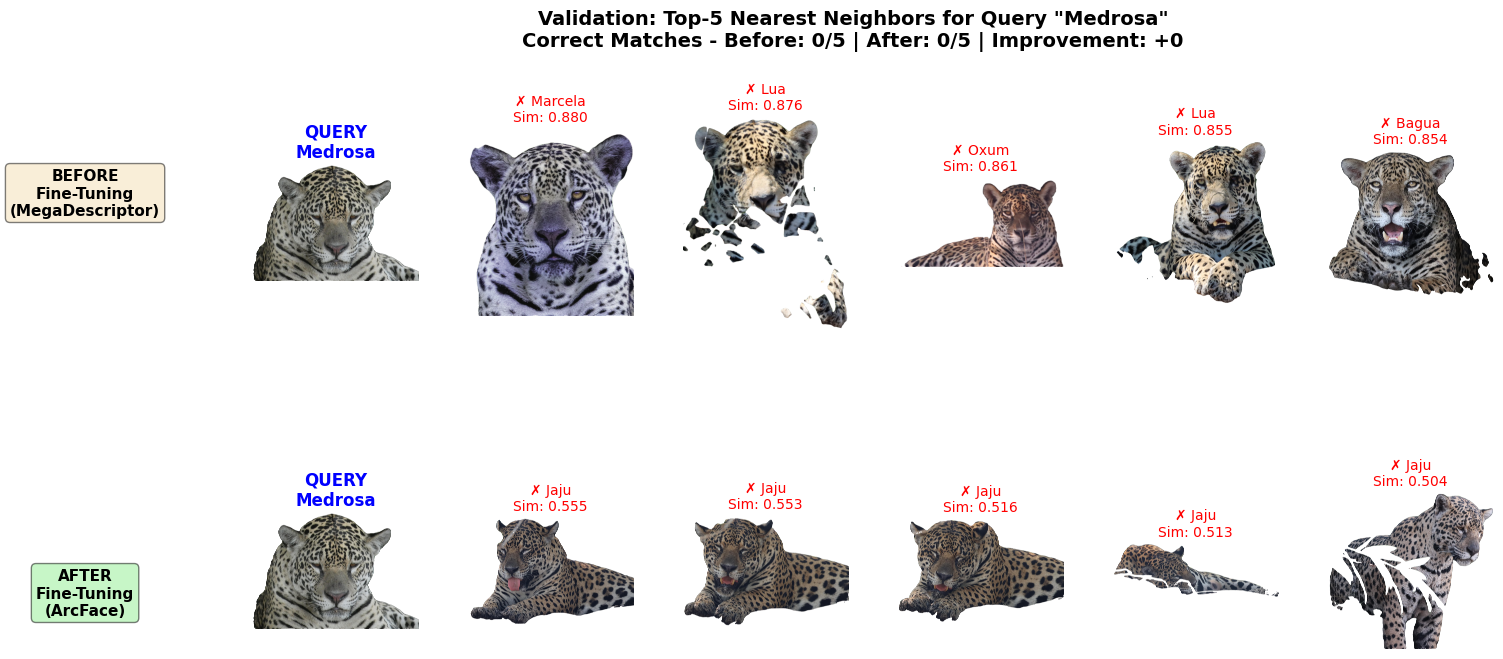

In [31]:
# Example 1: Random validation image
np.random.seed(RANDOM_SEED)
random_idx = np.random.randint(0, len(val_labels))

print(f"Example 1: Random query (index {random_idx})")
fig1, stats1 = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_val_embeddings,
    finetuned_embeddings=val_finetuned_embeddings,
    image_paths=val_image_paths,
    labels=val_labels,
    k=5
)
plt.show()

## 10. Generate Competition Submission

Now we generate predictions for the test set. The competition expects:
- A CSV with columns: `row_id`, `similarity`
- Each row corresponds to a query-gallery image pair from `test.csv`
- `similarity` is a float between 0 and 1

We:
1. Extract MegaDescriptor embeddings for all test images
2. Project through our fine-tuned model
3. Compute cosine similarity for each pair in `test.csv`
4. Clip values to [0, 1] and save as CSV

In [32]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [33]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [config["data_dir"] / "test/test" / filename for filename in test_images]

# Extract embeddings for test images using the BEST backbone (use best backbone)
print(f"\nExtracting test embeddings using BEST backbone: {best_overall_backbone}")
test_mega_embeddings = extract_embeddings(
    best_backbone_model,
    test_image_paths,
    best_transform,
    batch_size=config["batch_size"],
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_mega_embeddings.shape}")

Unique test images: 371

Extracting test embeddings using BEST backbone: DINOv2-ViT-L-14


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings shape: (371, 1024)


In [34]:
# Project through best backbone's fine-tuned model
# Extract test embeddings using best backbone + best trained projection head
print(f"Using BEST backbone for submission: {best_overall_backbone}")
best_model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = best_model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")
# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Using BEST backbone for submission: DINOv2-ViT-L-14
Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [35]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9962
  Mean: 0.0657
  Std: 0.1420


In [36]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(config["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.739830
1       1    0.000000
2       2    0.000000
3       3    0.243044
4       4    0.154411
5       5    0.000000
6       6    0.000000
7       7    0.064605
8       8    0.225468
9       9    0.000000

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [37]:
# Save submission
submission_path = config["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv("/kaggle/working/submission.csv", index=False)
print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: checkpoints/submission.csv
File size: 1794.1 KB


## 11. Save Artifacts to Weights and Biases

We save the best model checkpoint and this notebook as W&B artifacts for reproducibility.

In [38]:
# Save best backbone model as W&B artifact
# Use the checkpoint path saved during training for best backbone
best_checkpoint_path = backbone_results[best_overall_backbone]['checkpoint']

model_artifact = wandb.Artifact(
    name="arcface-best-backbone-model",
    type="model",
    description=f"ArcFace fine-tuned model with best backbone ({best_overall_backbone}) for jaguar re-identification"
)
model_artifact.add_file(best_checkpoint_path)
wandb.log_artifact(model_artifact)
print(f"Model artifact saved to W&B: {best_checkpoint_path}")

Model artifact saved to W&B: checkpoints/DINOv2-ViT-L-14_best.pth


In [39]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description="Competition submission file"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [40]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

ConvNeXt-V2-Base/backbone_dim,▁
ConvNeXt-V2-Base/best_epoch,▁
ConvNeXt-V2-Base/best_val_map,▁
ConvNeXt-V2-Base/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
ConvNeXt-V2-Base/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ConvNeXt-V2-Base/train_acc,▁▁▁▁▁▂▃▃▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
ConvNeXt-V2-Base/train_loss,█▇▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ConvNeXt-V2-Base/val_acc,▁▁▁▂▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇███████████████████
ConvNeXt-V2-Base/val_loss,█▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ConvNeXt-V2-Base/val_map,▁▁▂▃▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
+44,...


W&B run completed
